# Final Paper Figures Notebook

This notebook is a **focused, final-figures-only** version of the project.

It is designed to:
- load the raw datasets cheaply for **data overview** and **client split** figures,
- load cached CSV sweep outputs when available for **privacy–utility sweep** figures,
- use **hard-coded final summary tables** from the completed experiments for:
  - final method comparison,
  - MIA/privacy evaluation,
  - optional drift appendix plots.

The goal is to avoid rerunning heavy training and only regenerate the **keeper figures/tables** for the ACM paper.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="talk")

COLOR_NORMAL = "#1f77b4"
COLOR_MALICIOUS = "#d62728"
COLOR_DARK = "#2F2F2F"

# Final-paper knobs
LABEL_COL = "label"
TEST_SIZE = 0.2
N_CLIENTS = 8
DIRICHLET_ALPHA = 0.3
MIN_CLIENT_SIZE = 64
SEED = 42

SAVE_DIR = Path("final_paper_figures")
SAVE_DIR.mkdir(exist_ok=True)

def savefig(name: str, dpi: int = 300):
    out = SAVE_DIR / name
    plt.savefig(out, dpi=dpi, bbox_inches="tight")
    print(f"saved: {out.resolve()}")

In [2]:
# Resolve data / results paths robustly no matter where this notebook lives.

def find_first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None

cwd = Path.cwd()
candidate_dirs = [
    cwd,
    cwd / "data",
    cwd.parent,
    cwd.parent / "data",
]

ecu_path = find_first_existing([d / "cleaned_ecu.parquet" for d in candidate_dirs])
wustl_path = find_first_existing([d / "cleaned_wustl.parquet" for d in candidate_dirs])

ecu_sweep_path = find_first_existing(
    [d / "ecu_fixed_noise_sweep.csv" for d in candidate_dirs] +
    [d / "ecu_strict_fixed_noise_sweep.csv" for d in candidate_dirs]
)
wustl_sweep_path = find_first_existing(
    [d / "wustl_fixed_noise_sweep.csv" for d in candidate_dirs] +
    [d / "wustl_strict_fixed_noise_sweep.csv" for d in candidate_dirs]
)

print("ecu_path:", ecu_path)
print("wustl_path:", wustl_path)
print("ecu_sweep_path:", ecu_sweep_path)
print("wustl_sweep_path:", wustl_sweep_path)

ecu_path: /Users/mccayruddick/Documents/Computer_Science/CSC429/project/data/cleaned_ecu.parquet
wustl_path: /Users/mccayruddick/Documents/Computer_Science/CSC429/project/data/cleaned_wustl.parquet
ecu_sweep_path: None
wustl_sweep_path: None


## 1. Data overview

In [3]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc

pa.PyExtensionType.set_auto_load(True)

if ecu_path is None or wustl_path is None:
    raise FileNotFoundError("Could not find cleaned_ecu.parquet and/or cleaned_wustl.parquet")

def read_legacy_parquet(path):
    table = pq.read_table(path)

    for i, field in enumerate(table.schema):
        col = table.column(i)

        if pa.types.is_dictionary(col.type):
            decoded_col = pc.dictionary_decode(col)
            decoded_field = pa.field(
                field.name,
                decoded_col.type,
                nullable=field.nullable,
                metadata=field.metadata,
            )
            table = table.set_column(i, decoded_field, decoded_col)

    return table.to_pandas(ignore_metadata=True)

ecu_df = read_legacy_parquet(ecu_path)
wustl_df = read_legacy_parquet(wustl_path)

def make_dataset_summary_table(datasets: dict, label_col: str = LABEL_COL) -> pd.DataFrame:
    rows = []

    for name, df in datasets.items():
        if label_col not in df.columns:
            raise KeyError(f"{name}: missing label column {label_col}")

        counts = df[label_col].value_counts(dropna=False)
        majority_label = counts.idxmax()
        majority_count = counts.max()

        rows.append({
            "Dataset": name,
            "Rows": len(df),
            "Columns": df.shape[1],
            "Classes": df[label_col].nunique(dropna=False),
            "Majority label": majority_label,
            "Majority count": majority_count,
            "Majority percent": round(majority_count / len(df) * 100, 2),
        })

    return pd.DataFrame(rows)

summary_df = make_dataset_summary_table({
    "ECU-IoHT": ecu_df,
    "WUSTL-IIoT": wustl_df,
})

summary_df

,Dataset,Rows,Columns,Classes,Majority label,Majority count,Majority percent
0,ECU-IoHT,111207,6,2,1,87754,78.91
1,WUSTL-IIoT,16318,43,2,0,14272,87.46


saved: /Users/mccayruddick/Documents/Computer_Science/CSC429/project/data/final_paper_figures/fig_data_class_distribution.png


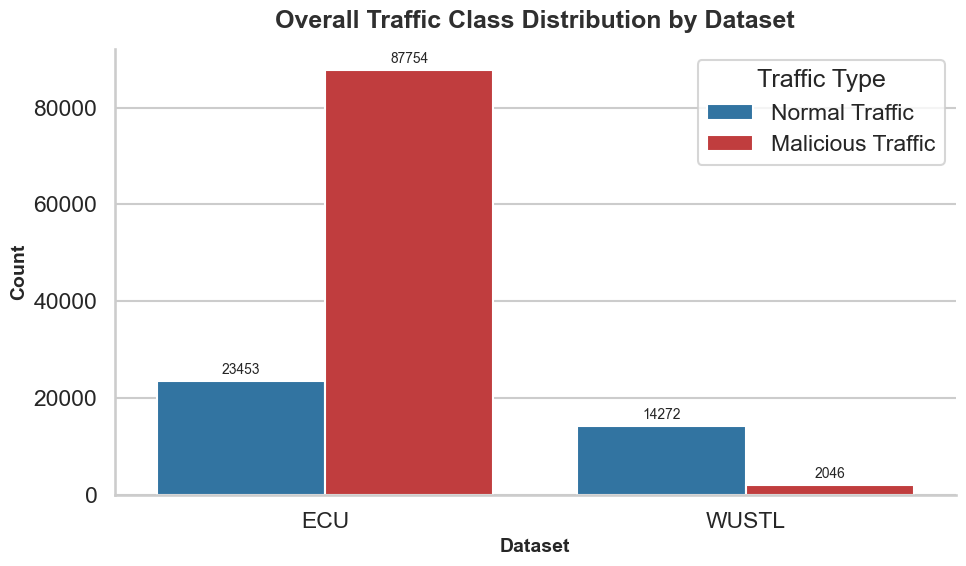

In [22]:
def plot_overall_class_distribution(datasets: dict, label_col: str = LABEL_COL):
    rows = []
    for dataset_name, df in datasets.items():
        counts = df[label_col].value_counts().sort_index()
        rows.append({"dataset": dataset_name, "traffic_type": "Normal Traffic", "count": int(counts.get(0, 0))})
        rows.append({"dataset": dataset_name, "traffic_type": "Malicious Traffic", "count": int(counts.get(1, 0))})

    plot_df = pd.DataFrame(rows)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=plot_df,
        x="dataset",
        y="count",
        hue="traffic_type",
        palette=[COLOR_NORMAL, COLOR_MALICIOUS],
    )
    ax.set_title("Overall Traffic Class Distribution by Dataset", fontsize=18, weight="bold", color=COLOR_DARK, pad=15)
    ax.set_xlabel("Dataset", fontsize=14, weight="bold")
    ax.set_ylabel("Count", fontsize=14, weight="bold")
    ax.legend(title="Traffic Type", frameon=True)

    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3, fontsize=10)

    sns.despine()
    plt.tight_layout()
    savefig("fig_data_class_distribution.png")
    plt.show()

plot_overall_class_distribution({"ECU": ecu_df, "WUSTL": wustl_df})

saved: /Users/mccayruddick/Documents/Computer_Science/CSC429/project/data/final_paper_figures/fig_data_class_ratio.png


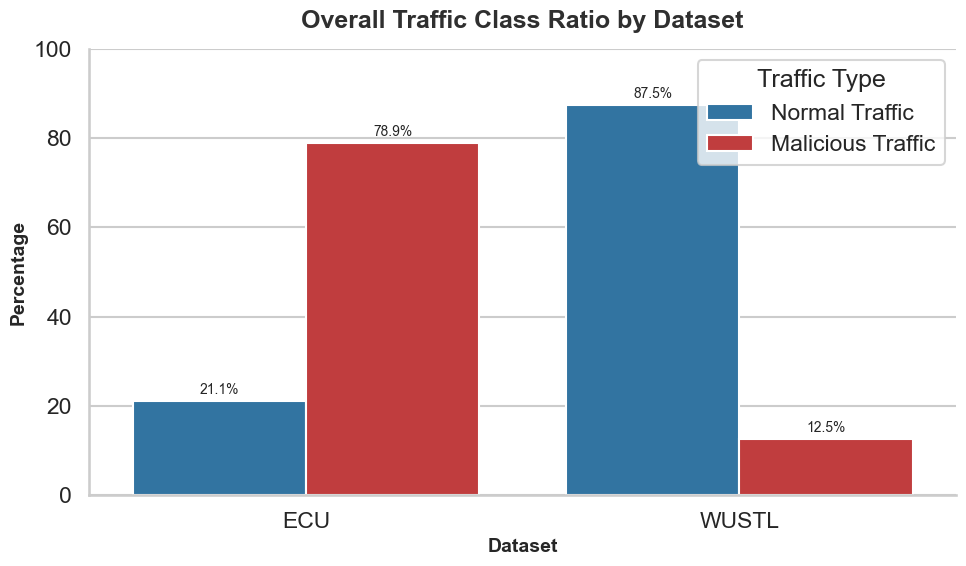

In [25]:
def plot_overall_class_distribution(datasets: dict, label_col: str = LABEL_COL):
    rows = []

    for dataset_name, df in datasets.items():
        counts = df[label_col].value_counts().sort_index()

        normal_count = counts.get(0, 0)
        malicious_count = counts.get(1, 0)
        total = normal_count + malicious_count

        normal_pct = (normal_count / total * 100) if total > 0 else 0
        malicious_pct = (malicious_count / total * 100) if total > 0 else 0

        rows.append({
            "dataset": dataset_name,
            "traffic_type": "Normal Traffic",
            "percent": normal_pct
        })

        rows.append({
            "dataset": dataset_name,
            "traffic_type": "Malicious Traffic",
            "percent": malicious_pct
        })

    plot_df = pd.DataFrame(rows)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=plot_df,
        x="dataset",
        y="percent",
        hue="traffic_type",
        palette=[COLOR_NORMAL, COLOR_MALICIOUS],
    )

    ax.set_title(
        "Overall Traffic Class Ratio by Dataset",
        fontsize=18,
        weight="bold",
        color=COLOR_DARK,
        pad=15
    )
    ax.set_xlabel("Dataset", fontsize=14, weight="bold")
    ax.set_ylabel("Percentage", fontsize=14, weight="bold")
    ax.set_ylim(0, 100)
    ax.legend(title="Traffic Type", frameon=True)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=10)

    sns.despine()
    plt.tight_layout()
    savefig("fig_data_class_ratio.png")
    plt.show()

plot_overall_class_distribution({"ECU": ecu_df, "WUSTL": wustl_df})

## 2. Heterogeneous client splits

In [5]:
def prepare_binary_tabular_data(
    df: pd.DataFrame,
    label_col: str = LABEL_COL,
    test_size: float = TEST_SIZE,
    random_state: int = SEED,
):
    y = df[label_col].astype(int).to_numpy()
    X_df = df.drop(columns=[label_col]).copy()

    for c in X_df.columns:
        if pd.api.types.is_bool_dtype(X_df[c]):
            X_df[c] = X_df[c].astype(int)

    train_df, test_df, y_train, y_test = train_test_split(
        X_df, y, test_size=test_size, stratify=y, random_state=random_state
    )

    train_df = pd.get_dummies(train_df, dummy_na=True)
    test_df = pd.get_dummies(test_df, dummy_na=True)
    train_df, test_df = train_df.align(test_df, join="left", axis=1, fill_value=0)

    scaler = StandardScaler()
    _ = scaler.fit_transform(train_df.astype(np.float32))
    _ = scaler.transform(test_df.astype(np.float32))

    return y_train.astype(np.int64), y_test.astype(np.int64)

def dirichlet_split_indices(
    y: np.ndarray,
    n_clients: int = N_CLIENTS,
    alpha: float = DIRICHLET_ALPHA,
    min_size: int = MIN_CLIENT_SIZE,
    seed: int = SEED,
):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    n_classes = len(np.unique(y))

    while True:
        client_indices = [[] for _ in range(n_clients)]

        for cls in range(n_classes):
            cls_idx = np.where(y == cls)[0]
            rng.shuffle(cls_idx)
            proportions = rng.dirichlet(alpha=np.repeat(alpha, n_clients))
            cuts = (np.cumsum(proportions) * len(cls_idx)).astype(int)[:-1]
            split_cls = np.split(cls_idx, cuts)

            for client_id, idx_chunk in enumerate(split_cls):
                client_indices[client_id].extend(idx_chunk.tolist())

        client_indices = [np.array(idx, dtype=int) for idx in client_indices]
        sizes = [len(idx) for idx in client_indices]
        if min(sizes) >= min_size:
            return client_indices

def make_client_split_table(y_train: np.ndarray, client_indices: list, dataset_name: str) -> pd.DataFrame:
    rows = []
    global_pos_rate = float(np.mean(y_train))

    for client_id, idx in enumerate(client_indices):
        y_client = y_train[idx]
        n_samples = len(idx)
        class_0_count = int(np.sum(y_client == 0))
        class_1_count = int(np.sum(y_client == 1))
        pos_rate = class_1_count / n_samples if n_samples > 0 else np.nan

        rows.append({
            "dataset": dataset_name,
            "client_id": client_id,
            "n_samples": n_samples,
            "class_0_count": class_0_count,
            "class_1_count": class_1_count,
            "positive_rate": float(pos_rate),
            "imbalance_vs_global": float(abs(pos_rate - global_pos_rate)),
        })

    return pd.DataFrame(rows)

ecu_y_train, _ = prepare_binary_tabular_data(ecu_df)
wustl_y_train, _ = prepare_binary_tabular_data(wustl_df)

ecu_client_indices = dirichlet_split_indices(ecu_y_train)
wustl_client_indices = dirichlet_split_indices(wustl_y_train)

ecu_client_split_df = make_client_split_table(ecu_y_train, ecu_client_indices, "ECU")
wustl_client_split_df = make_client_split_table(wustl_y_train, wustl_client_indices, "WUSTL")

display(ecu_client_split_df)
display(wustl_client_split_df)

,dataset,client_id,n_samples,class_0_count,class_1_count,positive_rate,imbalance_vs_global
0,ECU,0,1651,698,953,0.577226,0.211882
1,ECU,1,987,602,385,0.390071,0.399037
2,ECU,2,32090,38,32052,0.998816,0.209708
3,ECU,3,9741,9577,164,0.016836,0.772272
4,ECU,4,7499,7217,282,0.037605,0.751503
5,ECU,5,29219,448,28771,0.984668,0.195559
6,ECU,6,7675,142,7533,0.981498,0.192390
7,ECU,7,103,40,63,0.611650,0.177458


,dataset,client_id,n_samples,class_0_count,class_1_count,positive_rate,imbalance_vs_global
0,WUSTL,0,203,159,44,0.216749,0.091347
1,WUSTL,1,1008,323,685,0.679563,0.554161
2,WUSTL,2,1356,1275,81,0.059735,0.065668
3,WUSTL,3,1156,1156,0,0.000000,0.125402
4,WUSTL,4,481,481,0,0.000000,0.125402
5,WUSTL,5,1056,989,67,0.063447,0.061955
6,WUSTL,6,3130,3129,1,0.000319,0.125083
7,WUSTL,7,4664,3905,759,0.162736,0.037334


saved: /Users/mccayruddick/Documents/Computer_Science/CSC429/project/data/final_paper_figures/fig_client_split_normalized.png


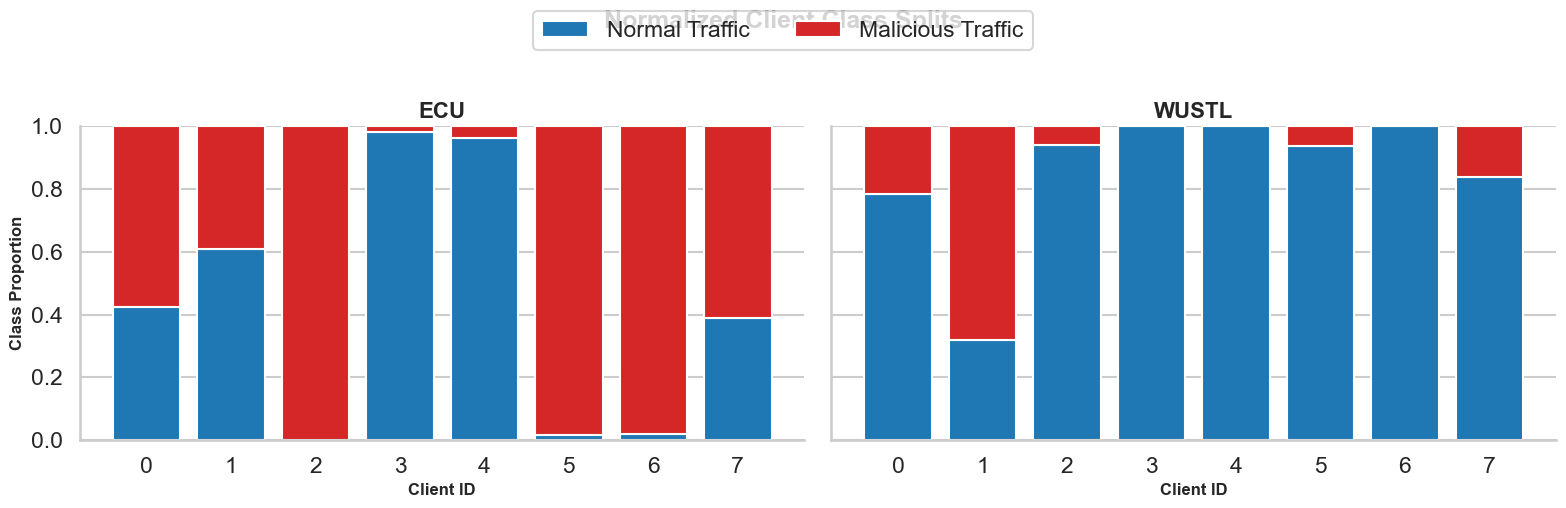

In [34]:
def plot_side_by_side_normalized_splits(ecu_client_split_df, wustl_client_split_df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, df, name in zip(
        axes,
        [ecu_client_split_df, wustl_client_split_df],
        ["ECU", "WUSTL"]
    ):
        tmp = df.copy().sort_values("client_id")
        class0 = tmp["class_0_count"].to_numpy(dtype=float)
        class1 = tmp["class_1_count"].to_numpy(dtype=float)
        totals = class0 + class1

        class0 = np.divide(class0, totals, out=np.zeros_like(class0), where=totals != 0)
        class1 = np.divide(class1, totals, out=np.zeros_like(class1), where=totals != 0)

        x = np.arange(len(tmp))
        ax.bar(x, class0, color=COLOR_NORMAL, label="Normal Traffic")
        ax.bar(x, class1, bottom=class0, color=COLOR_MALICIOUS, label="Malicious Traffic")
        ax.set_title(name, fontsize=16, weight="bold")
        ax.set_xlabel("Client ID", fontsize=12, weight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(tmp["client_id"])

    axes[0].set_ylabel("Class Proportion", fontsize=12, weight="bold")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=True)
    fig.suptitle("Normalized Client Class Splits", fontsize=18, weight="bold", y=1.03)
    sns.despine()
    plt.tight_layout()
    savefig("fig_client_split_normalized.png")
    plt.show()

plot_side_by_side_normalized_splits(ecu_client_split_df, wustl_client_split_df)

saved: /Users/mccayruddick/Documents/Computer_Science/CSC429/project/data/final_paper_figures/fig_client_split.png


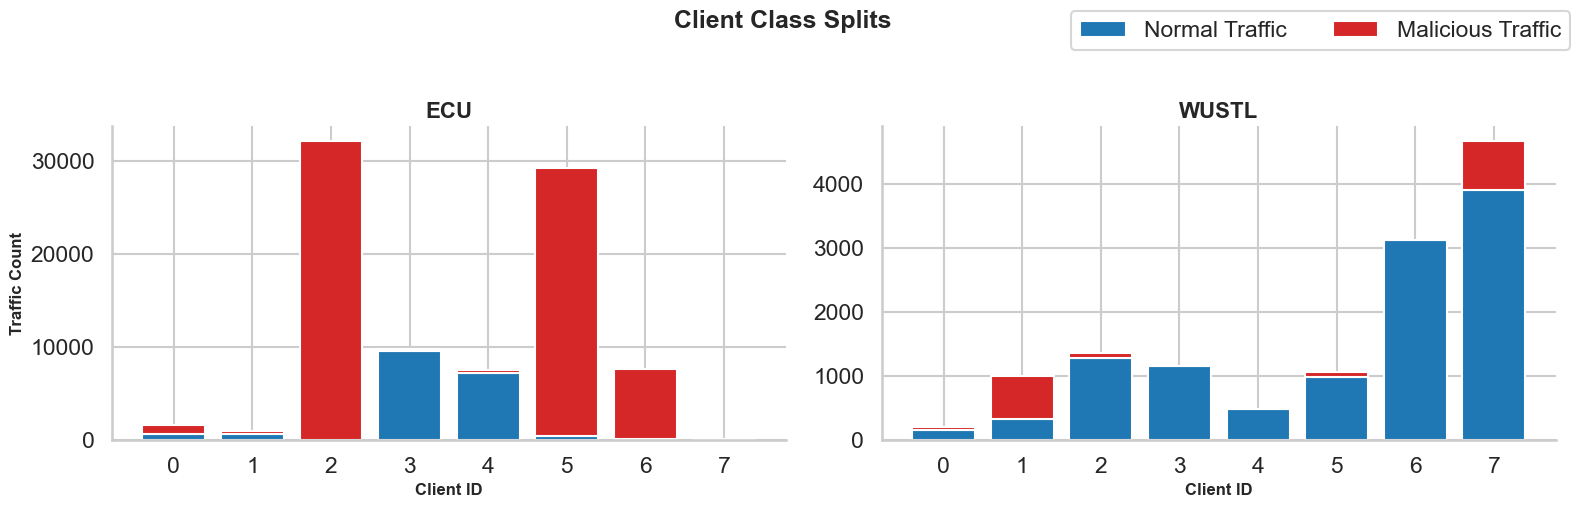

In [40]:
def plot_side_by_side_splits(ecu_client_split_df, wustl_client_split_df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

    for ax, df, name in zip(
        axes,
        [ecu_client_split_df, wustl_client_split_df],
        ["ECU", "WUSTL"]
    ):
        tmp = df.copy().sort_values("client_id")
        class0 = tmp["class_0_count"].to_numpy(dtype=float)
        class1 = tmp["class_1_count"].to_numpy(dtype=float)
        totals = class0 + class1

        class0 = tmp["class_0_count"].to_numpy(dtype=int)
        class1 = tmp["class_1_count"].to_numpy(dtype=int)

        x = np.arange(len(tmp))
        ax.bar(x, class0, color=COLOR_NORMAL, label="Normal Traffic")
        ax.bar(x, class1, bottom=class0, color=COLOR_MALICIOUS, label="Malicious Traffic")
        ax.set_title(name, fontsize=16, weight="bold")
        ax.set_xlabel("Client ID", fontsize=12, weight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(tmp["client_id"])

    axes[0].set_ylabel("Traffic Count", fontsize=12, weight="bold")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=2, frameon=True)
    fig.suptitle("Client Class Splits", fontsize=18, weight="bold", y=1.03)
    sns.despine()
    plt.tight_layout()
    savefig("fig_client_split.png")
    plt.show()

plot_side_by_side_splits(ecu_client_split_df, wustl_client_split_df)

## 3. Fixed-noise privacy–utility sweeps (cached CSVs)

In [7]:
if ecu_sweep_path is not None and wustl_sweep_path is not None:
    ecu_sweep_df = pd.read_csv(ecu_sweep_path)
    wustl_sweep_df = pd.read_csv(wustl_sweep_path)

    display(ecu_sweep_df)
    display(wustl_sweep_df)
else:
    print("Sweep CSVs not found. Expected one of:")
    print(" - ecu_fixed_noise_sweep.csv or ecu_strict_fixed_noise_sweep.csv")
    print(" - wustl_fixed_noise_sweep.csv or wustl_strict_fixed_noise_sweep.csv")

Sweep CSVs not found. Expected one of:
 - ecu_fixed_noise_sweep.csv or ecu_strict_fixed_noise_sweep.csv
 - wustl_fixed_noise_sweep.csv or wustl_strict_fixed_noise_sweep.csv


In [8]:
def _pick_metric_column(df, preferred):
    for c in preferred:
        if c in df.columns:
            return c
    return None

def plot_fixed_noise_sweeps(ecu_df_sweep, wustl_df_sweep):
    ecu_f1_col = _pick_metric_column(ecu_df_sweep, ["best_f1", "f1"])
    ecu_pr_col = _pick_metric_column(ecu_df_sweep, ["best_pr_auc", "pr_auc"])
    wustl_f1_col = _pick_metric_column(wustl_df_sweep, ["best_f1", "f1"])
    wustl_pr_col = _pick_metric_column(wustl_df_sweep, ["best_pr_auc", "pr_auc"])

    if any(v is None for v in [ecu_f1_col, ecu_pr_col, wustl_f1_col, wustl_pr_col]):
        raise ValueError("Could not find F1/PR-AUC columns in sweep CSVs.")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(ecu_df_sweep["sigma"], ecu_df_sweep[ecu_f1_col], marker="o", label="ECU F1", color="#1f77b4")
    axes[0].plot(wustl_df_sweep["sigma"], wustl_df_sweep[wustl_f1_col], marker="o", label="WUSTL F1", color="#d62728")
    axes[0].set_xscale("log")
    axes[0].set_title("Fixed-Noise Sweep: F1 vs Sigma")
    axes[0].set_xlabel("Noise Sigma")
    axes[0].set_ylabel("F1")
    axes[0].legend()

    axes[1].plot(ecu_df_sweep["sigma"], ecu_df_sweep[ecu_pr_col], marker="o", label="ECU PR-AUC", color="#1f77b4")
    axes[1].plot(wustl_df_sweep["sigma"], wustl_df_sweep[wustl_pr_col], marker="o", label="WUSTL PR-AUC", color="#d62728")
    axes[1].set_xscale("log")
    axes[1].set_title("Fixed-Noise Sweep: PR-AUC vs Sigma")
    axes[1].set_xlabel("Noise Sigma")
    axes[1].set_ylabel("PR-AUC")
    axes[1].legend()

    plt.tight_layout()
    savefig("fig_fixed_noise_sweeps.png")
    plt.show()

if ecu_sweep_path is not None and wustl_sweep_path is not None:
    plot_fixed_noise_sweeps(ecu_sweep_df, wustl_sweep_df)

## 4. Final method comparison (cached multi-seed summary)

In [9]:
multi_seed_summary_df = pd.DataFrame([
    # ECU Grouped Strict
    {"dataset":"ECU Grouped Strict","method":"adaptive_clip_q85_lr10_min085","f1_mean":0.995435,"f1_std":0.000053,"pr_auc_mean":0.999301,"pr_auc_std":0.000064,"auc_mean":0.998327,"auc_std":0.000178,"val_f1_mean":0.985665,"drift_mean":0.246829,"drift_std":0.003763,"rel_drift_mean":0.296760,"cosine_mean":0.951380,"cosine_std":0.018358,"global_step_mean":1.030994,"global_step_std":0.076724},
    {"dataset":"ECU Grouped Strict","method":"fedavg_no_dp","f1_mean":0.995435,"f1_std":0.000051,"pr_auc_mean":0.999240,"pr_auc_std":0.000180,"auc_mean":0.998149,"auc_std":0.000516,"val_f1_mean":0.985493,"drift_mean":0.0,"drift_std":0.0,"rel_drift_mean":0.0,"cosine_mean":1.0,"cosine_std":0.0,"global_step_mean":1.350606,"global_step_std":0.163811},
    {"dataset":"ECU Grouped Strict","method":"smoothed_sigma","f1_mean":0.995473,"f1_std":0.00000039,"pr_auc_mean":0.999372,"pr_auc_std":0.000040,"auc_mean":0.998526,"auc_std":0.000117,"val_f1_mean":0.985212,"drift_mean":0.196814,"drift_std":0.002506,"rel_drift_mean":0.249449,"cosine_mean":0.968481,"cosine_std":0.011544,"global_step_mean":0.851281,"global_step_std":0.044476},
    {"dataset":"ECU Grouped Strict","method":"fixed_noise","f1_mean":0.995112,"f1_std":0.000807,"pr_auc_mean":0.998716,"pr_auc_std":0.001360,"auc_mean":0.996567,"auc_std":0.003941,"val_f1_mean":0.985249,"drift_mean":0.165105,"drift_std":0.002395,"rel_drift_mean":0.212335,"cosine_mean":0.976268,"cosine_std":0.011238,"global_step_mean":0.841889,"global_step_std":0.059022},
    # WUSTL
    {"dataset":"WUSTL_strict_no_id","method":"adaptive_clip_q85_lr10_min085","f1_mean":0.706322,"f1_std":0.013853,"pr_auc_mean":0.723065,"pr_auc_std":0.016122,"auc_mean":0.862624,"auc_std":0.012326,"val_f1_mean":0.685436,"drift_mean":0.381417,"drift_std":0.022194,"rel_drift_mean":0.787507,"cosine_mean":0.803104,"cosine_std":0.030202,"global_step_mean":0.735802,"global_step_std":0.064814},
    {"dataset":"WUSTL_strict_no_id","method":"fedavg_no_dp","f1_mean":0.700145,"f1_std":0.003200,"pr_auc_mean":0.711573,"pr_auc_std":0.007337,"auc_mean":0.853471,"auc_std":0.007455,"val_f1_mean":0.680880,"drift_mean":0.0,"drift_std":0.0,"rel_drift_mean":0.0,"cosine_mean":1.0,"cosine_std":0.0,"global_step_mean":0.817095,"global_step_std":0.068581},
    {"dataset":"WUSTL_strict_no_id","method":"smoothed_sigma","f1_mean":0.699367,"f1_std":0.019272,"pr_auc_mean":0.721673,"pr_auc_std":0.017309,"auc_mean":0.863710,"auc_std":0.010561,"val_f1_mean":0.684321,"drift_mean":0.425864,"drift_std":0.015528,"rel_drift_mean":0.858245,"cosine_mean":0.779546,"cosine_std":0.031963,"global_step_mean":0.760335,"global_step_std":0.049514},
    {"dataset":"WUSTL_strict_no_id","method":"fixed_noise","f1_mean":0.699146,"f1_std":0.019112,"pr_auc_mean":0.721415,"pr_auc_std":0.017334,"auc_mean":0.863394,"auc_std":0.010569,"val_f1_mean":0.684321,"drift_mean":0.376671,"drift_std":0.011075,"rel_drift_mean":0.775546,"cosine_mean":0.808044,"cosine_std":0.031758,"global_step_mean":0.734203,"global_step_std":0.047850},
])

display(multi_seed_summary_df)

,dataset,method,f1_mean,f1_std,pr_auc_mean,pr_auc_std,auc_mean,auc_std,val_f1_mean,drift_mean,drift_std,rel_drift_mean,cosine_mean,cosine_std,global_step_mean,global_step_std
0,ECU Grouped Strict,adaptive_clip_q85_lr10_min085,0.995435,5.300000e-05,0.999301,0.000064,0.998327,0.000178,0.985665,0.246829,0.003763,0.296760,0.951380,0.018358,1.030994,0.076724
1,ECU Grouped Strict,fedavg_no_dp,0.995435,5.100000e-05,0.999240,0.000180,0.998149,0.000516,0.985493,0.000000,0.000000,0.000000,1.000000,0.000000,1.350606,0.163811
2,ECU Grouped Strict,smoothed_sigma,0.995473,3.900000e-07,0.999372,0.000040,0.998526,0.000117,0.985212,0.196814,0.002506,0.249449,0.968481,0.011544,0.851281,0.044476
3,ECU Grouped Strict,fixed_noise,0.995112,8.070000e-04,0.998716,0.001360,0.996567,0.003941,0.985249,0.165105,0.002395,0.212335,0.976268,0.011238,0.841889,0.059022
4,WUSTL_strict_no_id,adaptive_clip_q85_lr10_min085,0.706322,1.385300e-02,0.723065,0.016122,0.862624,0.012326,0.685436,0.381417,0.022194,0.787507,0.803104,0.030202,0.735802,0.064814
5,WUSTL_strict_no_id,fedavg_no_dp,0.700145,3.200000e-03,0.711573,0.007337,0.853471,0.007455,0.680880,0.000000,0.000000,0.000000,1.000000,0.000000,0.817095,0.068581
6,WUSTL_strict_no_id,smoothed_sigma,0.699367,1.927200e-02,0.721673,0.017309,0.863710,0.010561,0.684321,0.425864,0.015528,0.858245,0.779546,0.031963,0.760335,0.049514
7,WUSTL_strict_no_id,fixed_noise,0.699146,1.911200e-02,0.721415,0.017334,0.863394,0.010569,0.684321,0.376671,0.011075,0.775546,0.808044,0.031758,0.734203,0.047850


saved: /Users/mccayruddick/Documents/Computer_Science/CSC429/project/data/final_paper_figures/fig_final_method_comparison.png


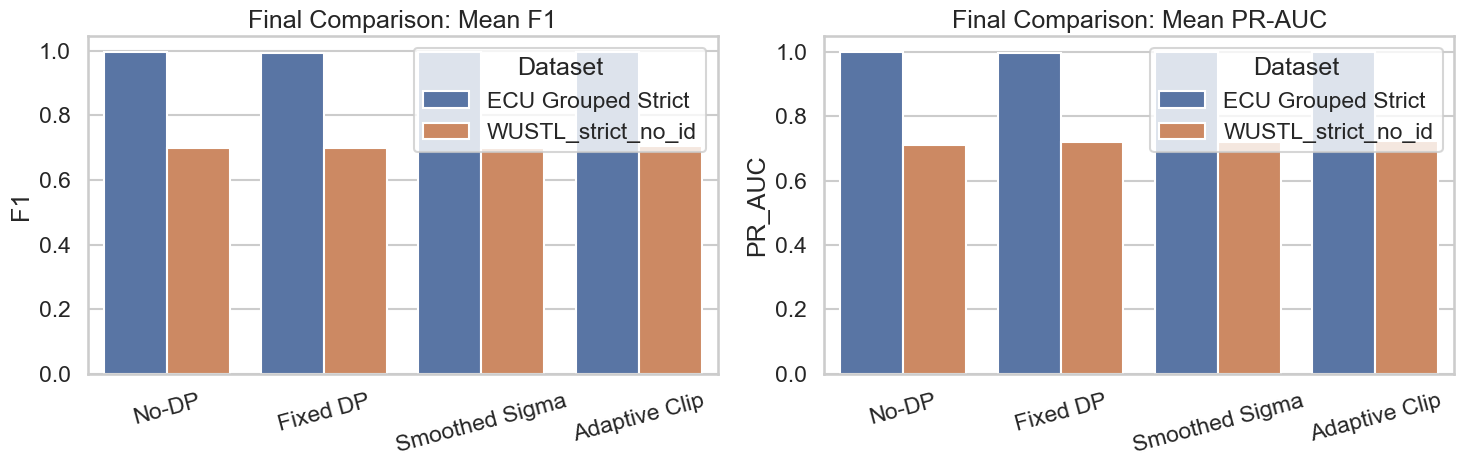

In [10]:
plot_df = multi_seed_summary_df.copy()

method_order = [
    "fedavg_no_dp",
    "fixed_noise",
    "smoothed_sigma",
    "adaptive_clip_q85_lr10_min085",
]
method_label_map = {
    "fedavg_no_dp": "No-DP",
    "fixed_noise": "Fixed DP",
    "smoothed_sigma": "Smoothed Sigma",
    "adaptive_clip_q85_lr10_min085": "Adaptive Clip",
}
plot_df["method_pretty"] = plot_df["method"].map(method_label_map)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, metric, title in zip(
    axes,
    ["f1_mean", "pr_auc_mean"],
    ["Final Comparison: Mean F1", "Final Comparison: Mean PR-AUC"]
):
    sns.barplot(
        data=plot_df,
        x="method_pretty",
        y=metric,
        hue="dataset",
        order=[method_label_map[m] for m in method_order],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric.replace("_mean", "").upper())
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="Dataset")

plt.tight_layout()
savefig("fig_final_method_comparison.png")
plt.show()

## 5. MIA / privacy evaluation (cached)

In [11]:
mia_df = pd.DataFrame([
    {"setting":"ECU Strict","strategy":"No DP","mia_accuracy":0.510000,"mia_balanced_accuracy":0.510000,"mia_auc":0.513689,"mia_advantage":0.027378,"loss_only_auc":0.514761},
    {"setting":"ECU Strict","strategy":"Fixed DP","mia_accuracy":0.511667,"mia_balanced_accuracy":0.511667,"mia_auc":0.517844,"mia_advantage":0.035689,"loss_only_auc":0.514933},
    {"setting":"ECU Strict","strategy":"Smoothed Sigma","mia_accuracy":0.511667,"mia_balanced_accuracy":0.511667,"mia_auc":0.517522,"mia_advantage":0.035044,"loss_only_auc":0.514550},
    {"setting":"WUSTL Strict","strategy":"No DP","mia_accuracy":0.507853,"mia_balanced_accuracy":0.518297,"mia_auc":0.503309,"mia_advantage":0.006618,"loss_only_auc":0.476477},
    {"setting":"WUSTL Strict","strategy":"Fixed DP","mia_accuracy":0.499127,"mia_balanced_accuracy":0.509469,"mia_auc":0.503846,"mia_advantage":0.007692,"loss_only_auc":0.476410},
    {"setting":"WUSTL Strict","strategy":"Smoothed Sigma","mia_accuracy":0.500873,"mia_balanced_accuracy":0.511465,"mia_auc":0.503162,"mia_advantage":0.006325,"loss_only_auc":0.476374},
    {"setting":"ECU With ID","strategy":"No DP","mia_accuracy":0.521667,"mia_balanced_accuracy":0.521667,"mia_auc":0.532389,"mia_advantage":0.064778,"loss_only_auc":0.508250},
    {"setting":"ECU With ID","strategy":"Fixed DP","mia_accuracy":0.500000,"mia_balanced_accuracy":0.500000,"mia_auc":0.521122,"mia_advantage":0.042244,"loss_only_auc":0.514828},
    {"setting":"ECU With ID","strategy":"Smoothed Sigma","mia_accuracy":0.518333,"mia_balanced_accuracy":0.518333,"mia_auc":0.515206,"mia_advantage":0.030411,"loss_only_auc":0.535217},
    {"setting":"WUSTL With ID","strategy":"No DP","mia_accuracy":0.994764,"mia_balanced_accuracy":0.994505,"mia_auc":0.992698,"mia_advantage":0.985397,"loss_only_auc":0.516264},
    {"setting":"WUSTL With ID","strategy":"Fixed DP","mia_accuracy":0.994764,"mia_balanced_accuracy":0.994505,"mia_auc":0.995897,"mia_advantage":0.991795,"loss_only_auc":0.510159},
    {"setting":"WUSTL With ID","strategy":"Smoothed Sigma","mia_accuracy":0.996510,"mia_balanced_accuracy":0.996337,"mia_auc":0.994615,"mia_advantage":0.989231,"loss_only_auc":0.512833},
])

display(mia_df)

,setting,strategy,mia_accuracy,mia_balanced_accuracy,mia_auc,mia_advantage,loss_only_auc
0,ECU Strict,No DP,0.510000,0.510000,0.513689,0.027378,0.514761
1,ECU Strict,Fixed DP,0.511667,0.511667,0.517844,0.035689,0.514933
2,ECU Strict,Smoothed Sigma,0.511667,0.511667,0.517522,0.035044,0.514550
3,WUSTL Strict,No DP,0.507853,0.518297,0.503309,0.006618,0.476477
4,WUSTL Strict,Fixed DP,0.499127,0.509469,0.503846,0.007692,0.476410
5,WUSTL Strict,Smoothed Sigma,0.500873,0.511465,0.503162,0.006325,0.476374
6,ECU With ID,No DP,0.521667,0.521667,0.532389,0.064778,0.508250
7,ECU With ID,Fixed DP,0.500000,0.500000,0.521122,0.042244,0.514828
8,ECU With ID,Smoothed Sigma,0.518333,0.518333,0.515206,0.030411,0.535217
9,WUSTL With ID,No DP,0.994764,0.994505,0.992698,0.985397,0.516264


saved: /Users/mccayruddick/Documents/Computer_Science/CSC429/project/data/final_paper_figures/fig_mia_results.png


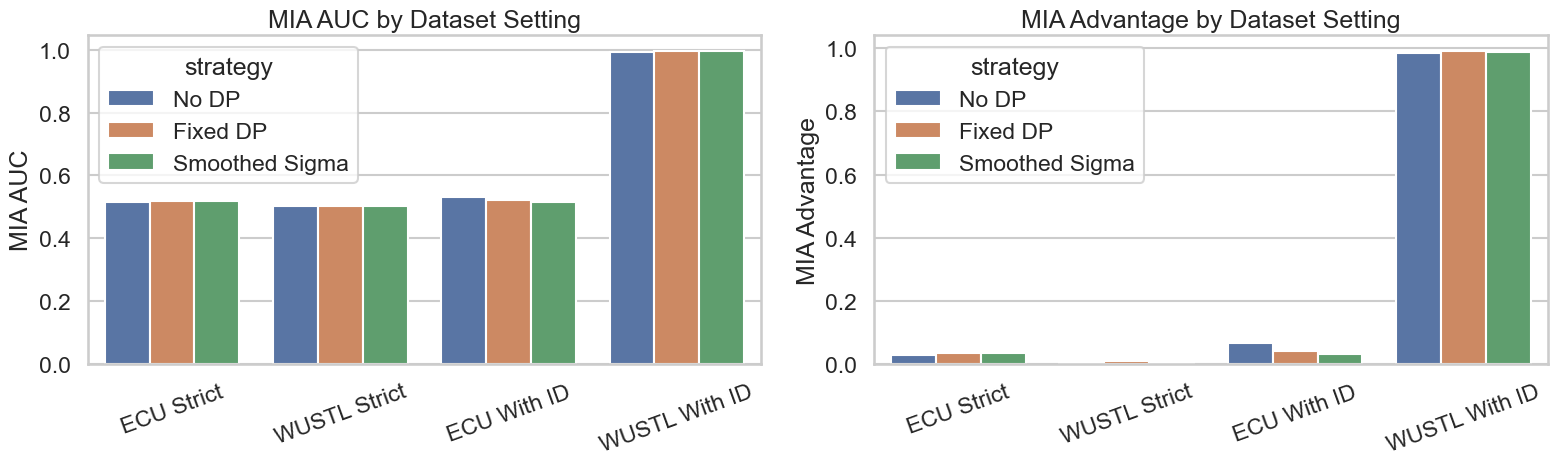

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

sns.barplot(
    data=mia_df,
    x="setting",
    y="mia_auc",
    hue="strategy",
    ax=axes[0],
)
axes[0].set_title("MIA AUC by Dataset Setting")
axes[0].set_xlabel("")
axes[0].set_ylabel("MIA AUC")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=mia_df,
    x="setting",
    y="mia_advantage",
    hue="strategy",
    ax=axes[1],
)
axes[1].set_title("MIA Advantage by Dataset Setting")
axes[1].set_xlabel("")
axes[1].set_ylabel("MIA Advantage")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
savefig("fig_mia_results.png")
plt.show()

## 6. Optional appendix: drift metrics

saved: /Users/mccayruddick/Documents/Computer_Science/CSC429/project/data/final_paper_figures/fig_wustl_drift_appendix.png


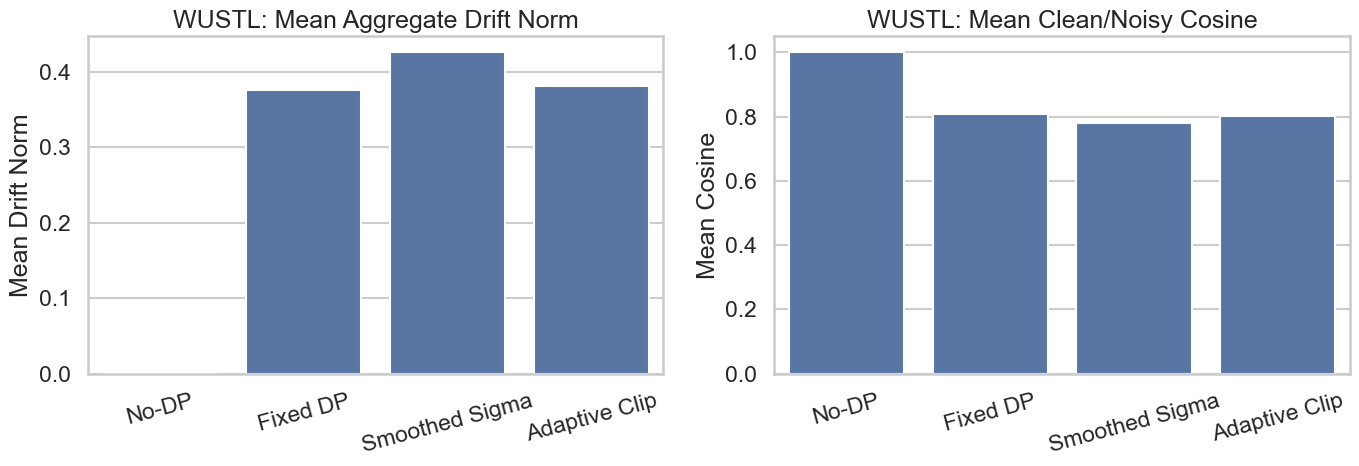

In [13]:
wustl_drift_appendix = multi_seed_summary_df[multi_seed_summary_df["dataset"] == "WUSTL_strict_no_id"].copy()
wustl_drift_appendix["method_pretty"] = wustl_drift_appendix["method"].map(method_label_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=wustl_drift_appendix,
    x="method_pretty",
    y="drift_mean",
    order=[method_label_map[m] for m in method_order],
    ax=axes[0],
)
axes[0].set_title("WUSTL: Mean Aggregate Drift Norm")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean Drift Norm")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(
    data=wustl_drift_appendix,
    x="method_pretty",
    y="cosine_mean",
    order=[method_label_map[m] for m in method_order],
    ax=axes[1],
)
axes[1].set_title("WUSTL: Mean Clean/Noisy Cosine")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean Cosine")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
savefig("fig_wustl_drift_appendix.png")
plt.show()

In [14]:
from pathlib import Path
import pickle

# Choose where to save it
output_dir = Path("saved_results")
output_dir.mkdir(exist_ok=True)

pickle_path = output_dir / "project_results.pkl"

# Put whatever variables you want to keep in here
results_to_save = {
    "ecu_df": ecu_df,
    "wustl_df": wustl_df,
    "summary_df": summary_df,
}

with open(pickle_path, "wb") as f:
    pickle.dump(results_to_save, f)

print(f"Saved results to: {pickle_path.resolve()}")

from pathlib import Path
import pickle

pickle_path = Path("saved_results/project_results.pkl")

with open(pickle_path, "rb") as f:
    saved_results = pickle.load(f)

ecu_df = saved_results["ecu_df"]
wustl_df = saved_results["wustl_df"]
summary_df = saved_results["summary_df"]

summary_df

Saved results to: /Users/mccayruddick/Documents/Computer_Science/CSC429/project/data/saved_results/project_results.pkl


,Dataset,Rows,Columns,Classes,Majority label,Majority count,Majority percent
0,ECU-IoHT,111207,6,2,1,87754,78.91
1,WUSTL-IIoT,16318,43,2,0,14272,87.46
